# 데이터과학 기말고사 (draft)
> 작성완료

- toc:false
- branch: master
- badges: false
- comments: false
- author: 최규빈
- categories: [데이터과학]

### Note 

- \#1,\#2, \#3은 동일하게 나옵니다.
- \#4는 바꿔서 나올 수 있습니다.


### \# 1.

아래와 같은 모형에서 100개의 sample $(x_i,y_i)$를 관찰하였다고 하자. 

$$y_i=\beta_0+\beta x_i+\epsilon_i, \quad \epsilon_i \sim N(0,1)$$

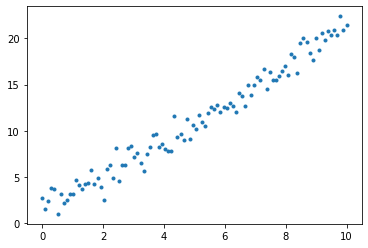

In [117]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
x=np.linspace(0,10,100)
y=1+2*x+np.random.normal(size=100)
plt.plot(x,y,'.')

`(1)` 오차제곱합의 최소값을 활용하여 $\beta$를 추정하고자 할때 적절한 손실함수를 쓰시오. 

`(2)` 최대우도함수의 최대값을 활용하여 $\beta$를 추정하고자 할때 적절한 손실함수를 쓰시오. 

`(3)` 다음은 tensorflow를 활용하여 모델을 학습하는 sample code이다. 

In [125]:
import tensorflow as tf
m1 = tf.keras.models.Sequential()
m1.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
m1.compile(loss='mse')
m1.fit(x,y,epochs=100,verbose=0)

학습결과를 시각화한 것은 아래와 같다. (blue: observed data, orange: predicted line)

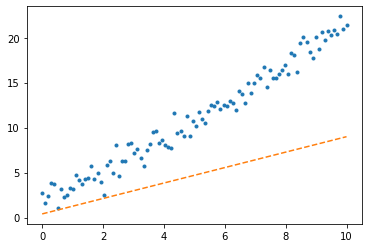

In [126]:
yhat=m1.predict(x)
plt.plot(x,y,'.')
plt.plot(x,yhat,'--')

학습한 계수값을 알기 위하여 아래를 실행하여 보고 추정된 $\hat{\beta}_0$, $\hat{\beta}_1$의 값을 쓰라. 
```python
m1.weights
```

`(4)` 아래는 학습성능을 향상시키기 위한 다양한 시도들이다. 

(a) epochs 증가
```python
modela = tf.keras.models.Sequential()
modela.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
modela.compile(loss='mse')
modela.fit(x,y,epochs=20000,verbose=0)
```

(b) epochs 증가 + 더 깊은 신경망 
```python
modelb = tf.keras.models.Sequential()
modelb.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
modelb.add(tf.keras.layers.Dense(1,activation='linear'))
modelb.compile(loss='mse')
modelb.fit(x,y,epochs=20000,verbose=0)
```

(c) epochs 증가 + 더 깊은 신경망 + 더 넓은 신경망 
```python
import tensorflow as tf
modelc = tf.keras.models.Sequential()
modelc.add(tf.keras.layers.Dense(20,input_shape=(1,),activation='linear'))
modelc.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
modelc.compile(loss='mse')
modelc.fit(x,y,epochs=20000,verbose=0)
```

위의 시도들 중 효과가 있다고 생각하는 방법과 그렇지 않은 방법을 모두 골라라. 

효과가 없다고 생각하는 방법은 그 이유를 서술하라. 

`(5)` 아래는 (4)-(b)의 모형으로 학습한 계수값을 나타낸것이다. 

In [128]:
modelb.weights

[<tf.Variable 'dense_16/kernel:0' shape=(1, 1) dtype=float32, numpy=array([[-1.9477649]], dtype=float32)>,
 <tf.Variable 'dense_16/bias:0' shape=(1,) dtype=float32, numpy=array([-0.5867223], dtype=float32)>,
 <tf.Variable 'dense_17/kernel:0' shape=(1, 1) dtype=float32, numpy=array([[-1.0083258]], dtype=float32)>,
 <tf.Variable 'dense_17/bias:0' shape=(1,) dtype=float32, numpy=array([0.6307], dtype=float32)>]

이 계수값을 바탕으로 $\hat{y}_i$와 $x_i$의 관계식을 쓰라. 

> Ex: $\hat{y}_i = 3(2 x_i +1)+1$